Paquetes necesarios

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Inicializaciones

In [2]:
#Dimensiones de la imagen a crear
ancho = 800
alto = 900

Imagen en grises

Muestra imagen con imshow (OpenCV). Observa que se muestra en ventana independiente

Muestra imagen con matplotlib

Imagen con tono de gris aleatorio

Asignamos valor a los píxeles de una zona concreta

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

Imagen en color

(800, 800, 3)


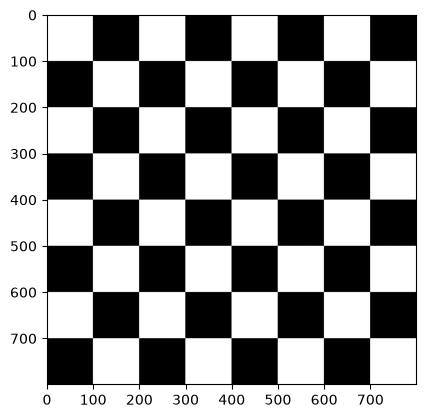

In [13]:
# Crea una imagen con tres planos
color_img = np.zeros((alto, ancho, 3), dtype=np.uint8)
print(color_img.shape)

# Visualiza con matplotlib (sin especificar el mapa de color gris)
# Ponemos que el tamaño cuadrado sea o con el ancho o con el alto porque son iguales. Y ponemos 8 porque un cuadrado de ajedrez es 8x8.
tamaño_cuadrado = alto // 8
y1, y2 = 0, tamaño_cuadrado
color_fila = 1 #0 = negro, 1 = blanco

while y2 <= alto:
    x1, x2 = 0, tamaño_cuadrado
    color = color_fila
    while x2 <= ancho:
        if color == 0:
            negro = [0, 0, 0]
            color_img[y1:y2, x1:x2] = negro
            color = 1
        else:
            blanco = [255, 255, 255]
            color_img[y1:y2, x1:x2] = blanco
            color = 0
        x1 += tamaño_cuadrado
        x2 += tamaño_cuadrado

    #Mantenemos el color de la ultima casilla de la fila para la siguiente fila
    if color_fila == 1:
        color_fila = 0
    else:
        color_fila = 1
    y1 += tamaño_cuadrado
    y2 += tamaño_cuadrado

plt.imshow(color_img)
plt.show()

###Version gemini###

#paso = 25
#for y in range(0, alto, paso):
#    for x in range(0, ancho, paso):
#        # Alterna blanco y negro según la suma de las coordenadas
#        color = [255, 255, 255] if (x // paso + y // paso) % 2 == 0 else [0, 0, 0]
#        color_img[y:y + paso, x:x + paso] = color


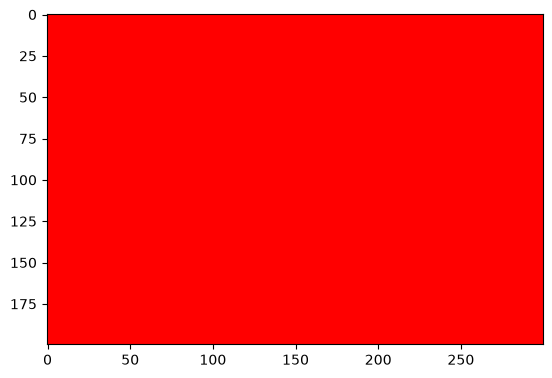

In [ ]:
#Modifica el primer plano de color (Rojo, ya que es RGB)
color_img[:,:,0] = 255 
#color_img[:,:,1] = 200 #Prueba otras combinaciones
#color_img[:,:,2] = 255 
plt.imshow(color_img) 
plt.show()

Funciones de dibujo.
OpenCV dispone de funciones específicas para dibujar formas básicas (más información https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html )

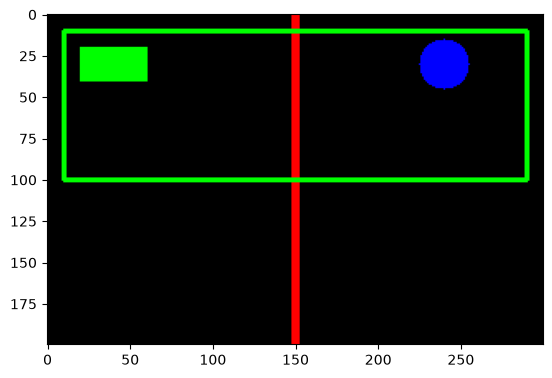

True

In [ ]:
#Crea una imagen con tres planos
color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

#Línea roja vertical de grosor 3
cv2.line(color_img,(int(ancho/2),0),(int(ancho/2),alto),(255,0,0),3)
#Rectángulo con grosor 2
cv2.rectangle(color_img,(10,10),(ancho-10,int(alto/2)),(0,255,0),2)
#Rectángulo relleno
cv2.rectangle(color_img,(20,20),(60,40),(0,255,0),-1)
#Círculo de radio 15 relleno
cv2.circle(color_img,(ancho-60,30), 15, (0,0,255), -1)
#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

In [ ]:
def click_raton(evento, x, y, flags, param):
    #Evento para detectar si clickeamos el botón izquierdo del ratón
    if evento == cv2.EVENT_LBUTTONDOWN:
        img = param
        b, g, r = img[y, x]

        if (b, g, r) == (0, 0, 0):
            print("Línea negra")
        elif (b, g, r) == (255, 255, 255):
            print("Blanco")
        elif (b, g, r) == (0, 255, 255):
            print("Amarillo")
        elif (b, g, r) == (0, 0, 255):
            print("Rojo")
        elif (b, g, r) == (255, 0, 0):
            print("Azul")
        elif (b, g, r) == (0, 255, 0):
            print("Verde")
        else:
            print(f"Color no registrado: BGR=({b}, {g}, {r})")
            
cv2.namedWindow("Mondrian")
cv2.setMouseCallback("Mondrian", click_raton, param=color_img)

#Bucle para que siempre esté atento al rectángulo que clickeamos
while True:
    cv2.imshow("Mondrian", color_img)
    tecla = cv2.waitKey(20) & 0xFF
    if tecla == 27 or tecla == ord('q'):
        break

cv2.destroyAllWindows()

Amarillo
Azul
Rojo
Línea negra
Línea negra
Blanco


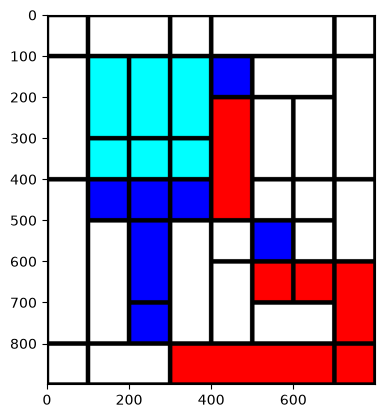

In [10]:
color_img = np.full((alto,ancho,3), 255, dtype = np.uint8)
cv2.rectangle(color_img,(0, 0), (int(ancho // 8), int(alto // 9)), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8), int(alto // 9)), (int(ancho // 8) * 3, 0), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9)), (int(ancho // 8) * 4, 0), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 4, int(alto // 9)), (int(ancho // 8) * 7, 0), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 7, int(alto // 9)), (ancho, 0), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9)), (int(ancho // 8) * 3, int(alto // 9) * 3), (0, 255, 255), -1)
cv2.rectangle(color_img,(0, int(alto // 9)), (int(ancho // 8), int(alto // 9) * 4), (0, 0, 0), 10)
#Pintamos el grsosr para que se vean las lineas de los rectangulos
cv2.rectangle(color_img,(int(ancho // 8), int(alto // 9)), (int(ancho // 8) * 2, int(alto // 9) * 3), (0, 255, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8), int(alto // 9)), (int(ancho // 8) * 2, int(alto // 9) * 3), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9)), (int(ancho // 8) * 3, int(alto // 9) * 3), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 1), (int(ancho // 8) * 4, int(alto // 9) * 3), (0, 255, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 1), (int(ancho // 8) * 4, int(alto // 9) * 3), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 4, int(alto // 9) * 1), (int(ancho // 8) * 5, int(alto // 9) * 2), (0, 0, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 4, int(alto // 9) * 1), (int(ancho // 8) * 5, int(alto // 9) * 2), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 1), (int(ancho // 8) * 7, int(alto // 9) * 2), (255, 255, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 1), (int(ancho // 8) * 7, int(alto // 9) * 2), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 1, int(alto // 9) * 3), (int(ancho // 8) * 2, int(alto // 9) * 4), (0, 255, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 1, int(alto // 9) * 3), (int(ancho // 8) * 2, int(alto // 9) * 4), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 3), (int(ancho // 8) * 3, int(alto // 9) * 4), (0, 255, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 3), (int(ancho // 8) * 3, int(alto // 9) * 4), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 3), (int(ancho // 8) * 4, int(alto // 9) * 4), (0, 255, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 3), (int(ancho // 8) * 4, int(alto // 9) * 4), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 4, int(alto // 9) * 2), (int(ancho // 8) * 5, int(alto // 9) * 5), (255, 0, 0), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 4, int(alto // 9) * 2), (int(ancho // 8) * 5, int(alto // 9) * 5), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 2), (int(ancho // 8) * 6, int(alto // 9) * 4), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 6, int(alto // 9) * 2), (int(ancho // 8) * 7, int(alto // 9) * 4), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 7, int(alto // 9) * 1), (int(ancho // 8) * 8, int(alto // 9) * 4), (0, 0, 0), 10)
cv2.rectangle(color_img,(0, int(alto // 9) * 4), (int(ancho // 8) * 1, int(alto // 9) * 8), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 1, int(alto // 9) * 4), (int(ancho // 8) * 2, int(alto // 9) * 5), (0, 0, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 1, int(alto // 9) * 4), (int(ancho // 8) * 2, int(alto // 9) * 5), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 4), (int(ancho // 8) * 3, int(alto // 9) * 5), (0, 0, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 4), (int(ancho // 8) * 3, int(alto // 9) * 5), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 4), (int(ancho // 8) * 4, int(alto // 9) * 5), (0, 0, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 4), (int(ancho // 8) * 4, int(alto // 9) * 5), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 4), (int(ancho // 8) * 6, int(alto // 9) * 5), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 6, int(alto // 9) * 4), (int(ancho // 8) * 7, int(alto // 9) * 5), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 7, int(alto // 9) * 4), (int(ancho // 8) * 8, int(alto // 9) * 6), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 5), (int(ancho // 8) * 3, int(alto // 9) * 7), (0, 0, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 5), (int(ancho // 8) * 3, int(alto // 9) * 7), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 5), (int(ancho // 8) * 4, int(alto // 9) * 8), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 4, int(alto // 9) * 5), (int(ancho // 8) * 5, int(alto // 9) * 6), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 1, int(alto // 9) * 5), (int(ancho // 8) * 2, int(alto // 9) * 8), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 5), (int(ancho // 8) * 6, int(alto // 9) * 6), (0, 0, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 5), (int(ancho // 8) * 6, int(alto // 9) * 6), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 6, int(alto // 9) * 5), (int(ancho // 8) * 7, int(alto // 9) * 6), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 7), (int(ancho // 8) * 3, int(alto // 9) * 8), (0, 0, 255), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 2, int(alto // 9) * 7), (int(ancho // 8) * 3, int(alto // 9) * 8), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 4, int(alto // 9) * 6), (int(ancho // 8) * 5, int(alto // 9) * 8), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 6), (int(ancho // 8) * 6, int(alto // 9) * 7), (255, 0, 0), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 6), (int(ancho // 8) * 6, int(alto // 9) * 7), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 6, int(alto // 9) * 6), (int(ancho // 8) * 7, int(alto // 9) * 7), (255, 0, 0), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 6, int(alto // 9) * 6), (int(ancho // 8) * 7, int(alto // 9) * 7), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 7, int(alto // 9) * 6), (int(ancho // 8) * 8, int(alto // 9) * 8), (255, 0, 0), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 7, int(alto // 9) * 6), (int(ancho // 8) * 8, int(alto // 9) * 8), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 5, int(alto // 9) * 7), (int(ancho // 8) * 7, int(alto // 9) * 8), (0, 0, 0), 10)
cv2.rectangle(color_img,(0, int(alto // 9) * 8), (int(ancho // 8) * 1, int(alto // 9) * 9), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 1, int(alto // 9) * 8), (int(ancho // 8) * 3, int(alto // 9) * 9), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 8), (int(ancho // 8) * 7, int(alto // 9) * 9), (255, 0, 0), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 3, int(alto // 9) * 8), (int(ancho // 8) * 7, int(alto // 9) * 9), (0, 0, 0), 10)
cv2.rectangle(color_img,(int(ancho // 8) * 7, int(alto // 9) * 8), (int(ancho // 8) * 8, int(alto // 9) * 9), (255, 0, 0), -1)
cv2.rectangle(color_img,(int(ancho // 8) * 7, int(alto // 9) * 8), (int(ancho // 8) * 8, int(alto // 9) * 9), (0, 0, 0), 10)

plt.imshow(color_img) 
plt.show()

Abrir imagen almacenada en disco

(1200, 1180, 3)


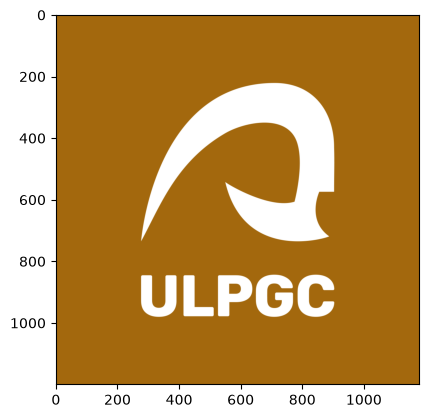

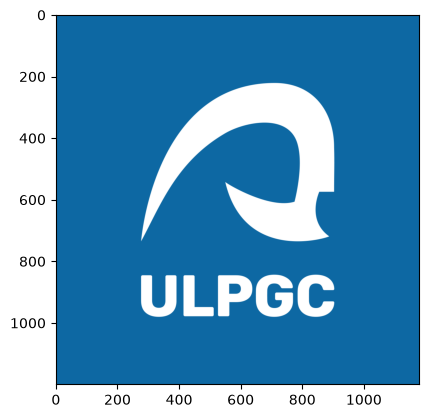

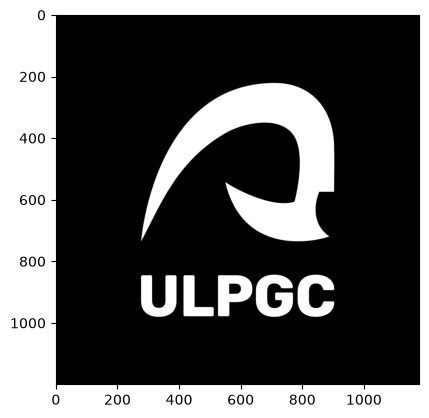

In [11]:
#Carga imagen desde disco
img = cv2.imread('logo_ulpgc_vertical_acronimo_mancheta_azul.png') 
#Dimensiones
print(img.shape)
#Muestra
plt.imshow(img) 
plt.show()

#OpenCV lee las imágenes de disco en formato BGR, por lo que convertimos para visualizr RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) 
plt.show()

#Fuerza lectura en grises
img = cv2.imread('logo_ulpgc_vertical_acronimo_mancheta_azul.png', cv2.IMREAD_GRAYSCALE) 
plt.imshow(img, cmap='gray') 
plt.show()


Abre un archivo de vídeo

In [12]:
# Abre vídeo
vid = cv2.VideoCapture('VermeerFun.mp4') 
  
# En caso de estar abierto
if vid.isOpened():
    while(True):      
        # fotograma a fotograma
        ret, frame = vid.read()

        # Hay nuevo fotograma
        if ret:  
            # Muestra fotograma
            cv2.imshow('Vid', frame)
        
        # Detenemos pulsado ESC
        if cv2.waitKey(20) == 27:
            break
    
    # Libera el objeto de captura
    vid.release()
    # Destruye ventanas
    cv2.destroyAllWindows()

KeyboardInterrupt: 

Muestra entrada de la cámara

In [13]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:  
        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

Separa los tres planos de la imagen captada por la webcam y muestra en horizontal

In [6]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Separamos canales
        b = frame[:,:,0]
        g = frame[:,:,1]
        r = frame[:,:,2]
        #Dimensiones imagen de entrada
        h, w, c = frame.shape

        #Concateamos en horizontal los tres planos del fotograma
        collage = np.hstack((r, g, b))
    
        # Muestra fotograma redimensionando a la mitad para que quepa en pantalla
        cv2.imshow('RGB', cv2.resize(collage, (int(w*1.5),int(h/2)),cv2.INTER_NEAREST))
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Evento de ratón para mostrar el valor RGB del píxel

In [15]:
# Función que trata eventos de ratón 
def mouse_events(event, x, y, flags, params):
    global px, py, R, G, B
    px = -1
    # Movimiento del puntero     
    if event==cv2.EVENT_MOUSEMOVE:
        #Valores del píxel, desde la webcam no es BGR
        B = frame[y, x, 0]
        G = frame[y, x, 1]
        R = frame[y, x, 2]  
        # Almacena valores del evento
        px = x
        py = y

     
  

In [16]:
vid = cv2.VideoCapture(0)

# Tipografía para mostrar texto
font = cv2.FONT_HERSHEY_SIMPLEX
  
lanzado = 0 #bandera para primer fotograma
px = -1
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 
        # Activa el manejador en el primer fotograma
        if lanzado == 0:
            # Muestra fotograma
            cv2.imshow('Cam', frame)   
            # Define el nombre del manejador del evento
            cv2.setMouseCallback('Cam', mouse_events)
            lanzado = 1
            
        # Muestra valores RGB intentando centrar en el puntero
        if px > -1:
            cv2.putText(frame, '{}'.format(R), (px-45,py-5), font, 0.5, (0, 0, 255), 1)
            cv2.putText(frame, '     {}'.format(G), (px-54,py-5), font, 0.5, (0, 255, 0), 1)
            cv2.putText(frame, '         {}'.format(B), (px-54,py-5), font, 0.5, (255, 0, 0), 1)
            
        cv2.imshow('Cam', frame)   
        
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [ ]:
vid = cv2.VideoCapture(0)

while(True):
    ret, frame = vid.read()
    if ret:
        altura, anchura, _ = frame.shape
        maxino_brillo = 0
        #Guardamos las coordenadas para saber donde ponemos el circulo.
        coord_y = 0
        coord_x = 0
        #Las coordenadas de y, x coinciden con las coordenadas de la imagen.
        for y in range(altura):
            for x in range(anchura):
                pixel = frame[y, x]
                brillo_actual = int(pixel[0]) + int(pixel[1]) + int(pixel[2])
                if brillo_actual > maxino_brillo:
                    maxino_brillo = brillo_actual
                    coord_y = y
                    coord_x = x

        cv2.circle(frame, (coord_x, coord_y), 10, (0, 0, 255), 2)
        cv2.imshow('Cam', frame)
        
    if cv2.waitKey(1) == 27:
        break
            
vid.release()
cv2.destroyAllWindows() 

#Forma IA

#vid = cv2.VideoCapture(0)

#while True:
#    ret, frame = vid.read()
#    if ret:
#        # Suma los 3 canales a lo largo del eje 2 (BGR) en un solo paso
#        # Se convierte a uint16/int para evitar desbordamiento (255+255+255 = 765 > 255)
#        mapa_brillo = frame.sum(axis=2)
#
#        # np.unravel_index junto con argmax localiza el índice (y, x) del píxel más alto
#        coord_y, coord_x = np.unravel_index(np.argmax(mapa_brillo), mapa_brillo.shape)
#
#        cv2.circle(frame, (int(coord_x), int(coord_y)), 10, (0, 0, 255), 2)
#        cv2.imshow('Cam', frame)
#
#    if cv2.waitKey(1) == 27:
#        break

#vid.release()
#cv2.destroyAllWindows()

Pop art
Salida de la webcam "inspirada" en Andy Warhol (Marilyn, https://temasycomentariosartepaeg.blogspot.com/p/autor-andy-warhol-1928-1987-titulo.html)

In [5]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tr = collage[0:h,w:w+w]
bl = collage[h:h+h,0:w]
br = collage[h:h+h,w:w+w]

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        tl[:,:,0] = b
        tl[:,:,1] = g
        tl[:,:,2] = r

        tr[:,:,0] = 255 - r
        tr[:,:,1] = g
        tr[:,:,2] = b
        
        bl[:,:,0] = r
        bl[:,:,1] = 255 - b
        bl[:,:,2] = g

        br[:,:,0] = b
        br[:,:,1] = g
        br[:,:,2] = 255 - r
    
        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Transformando la imagen capturada en una colección de círculos, cuyo radio depende de la intensidad promedio de la zona

In [18]:
vid = cv2.VideoCapture(0)

# Se define el número de celdas
ncells = 10
off = int(ncells/2)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        #Dimensiones originales
        h, w, c = frame.shape
        #Redimensiono teniendo en cuenta ncells
        down_frame = cv2.resize(frame, (int(w/ncells),int(h/ncells)),cv2.INTER_NEAREST)
        #Dimensiones reducidas
        h2, w2, c2 = down_frame.shape

        #Separamos canales
        r = down_frame[:,:,0]
        g = down_frame[:,:,1]
        b = down_frame[:,:,2]

        # Creamos imagen negra
        gris_up_frame = np.zeros((h2*ncells,w2*ncells,1), dtype = np.uint8)

        # recorre valores de la imagen reducida
        for y in range(0,h2):
            for x in range(0,w2):
                # La suma de los valores RGB define el radio del círculo
                rad = int ( (r[y,x] + g[y,x] + b[y,x])/(ncells*3*2))
                cv2.circle(gris_up_frame,(x*ncells+off, y*ncells + off), rad, (255,255,255), -1)

    
        # Muestra fotograma resultante
        cv2.imshow('Cam', gris_up_frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

KeyboardInterrupt: 

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

w=int(w/3)
h=int(h/3)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w)
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

collage = np.zeros((h*3,w*3,3), dtype = np.uint8)

cam1 = collage[0:h,0:w]
cam2 = collage[0:h,w:2*w]
cam3 = collage[0:h,2*w:3*w]
cam4 = collage[h:2*h,0:w]
cam5 = collage[h:2*h,w:2*w]
cam6 = collage[h:2*h,2*w:3*w]
cam7 = collage[2*h:3*h,0:w]
cam8 = collage[2*h:3*h,w:2*w]
cam9 = collage[2*h:3*h,2*w:3*w]

while True:
    
    ret, frame = vid.read()
    
    if ret:
        
        frame_redimensionado = cv2.resize(frame, (w, h), interpolation=cv2.INTER_NEAREST)

        #Obtener gris y los canales desde la imagen ya reducida
        gris = cv2.cvtColor(frame_redimensionado, cv2.COLOR_BGR2GRAY)

        cam1[:, :, 0] = 0
        cam1[:, :, 1] = gris // 2
        cam1[:, :, 2] = gris

        cam2[:, :, 0] = gris
        cam2[:, :, 1] = 0
        cam2[:, :, 2] = 0

        cam3[:, :, 0] = 0
        cam3[:, :, 1] = gris
        cam3[:, :, 2] = gris

        cam4[:, :, 0] = gris
        cam4[:, :, 1] = 0
        cam4[:, :, 2] = gris

        cam5[:, :, 0] = gris
        cam5[:, :, 1] = gris
        cam5[:, :, 2] = 0

        cam6[:, :, 0] = gris // 3
        cam6[:, :, 1] = gris
        cam6[:, :, 2] = 0

        cam7[:, :, 0] = 0
        cam7[:, :, 1] = 0
        cam7[:, :, 2] = gris

        cam8[:, :, 0] = gris
        cam8[:, :, 1] = 0
        cam8[:, :, 2] = gris // 2

        cam9[:, :, 0] = gris // 2
        cam9[:, :, 1] = gris // 2
        cam9[:, :, 2] = gris
        
        cv2.imshow('Cam', collage)
        
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

#Fuentes consultadas

#Comando cv2.resize
#https://www.geeksforgeeks.org/python/image-resizing-using-opencv-python/

#Comando cv2.cvtColor
#https://www.geeksforgeeks.org/python/python-opencv-cv2-cvtcolor-method/